<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/06_sam3_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAM 3 exploration

## Install necessary dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%matplotlib inline

In [ ]:
!pip install triton decord  > /dev/null

In [ ]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"  > /dev/null
%cd /content

!pip install -q supervision jupyter_bbox_widget  > /dev/null

fatal: destination path 'sam3' already exists and is not an empty directory.
/content/sam3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.36.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.2

In [ ]:
import os
os.path.isfile("/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz")

True

In [ ]:
import sam3
from sam3.sam3 import build_sam3_image_model
import os
# sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")
bpe_path = f"/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"

In [ ]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

## Build model

In [ ]:
model = build_sam3_image_model(bpe_path=bpe_path)

In [ ]:
BASE_DIR = "/content/drive/MyDrive/MSc_Thesis_Neuroimaging"

## Try model with a test image

In [ ]:
from PIL import Image
from sam3.model.sam3_image_processor import Sam3Processor
image_path = f"{BASE_DIR}/cat.jpg"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.5)
inference_state = processor.set_image(image)

found 1 object(s)


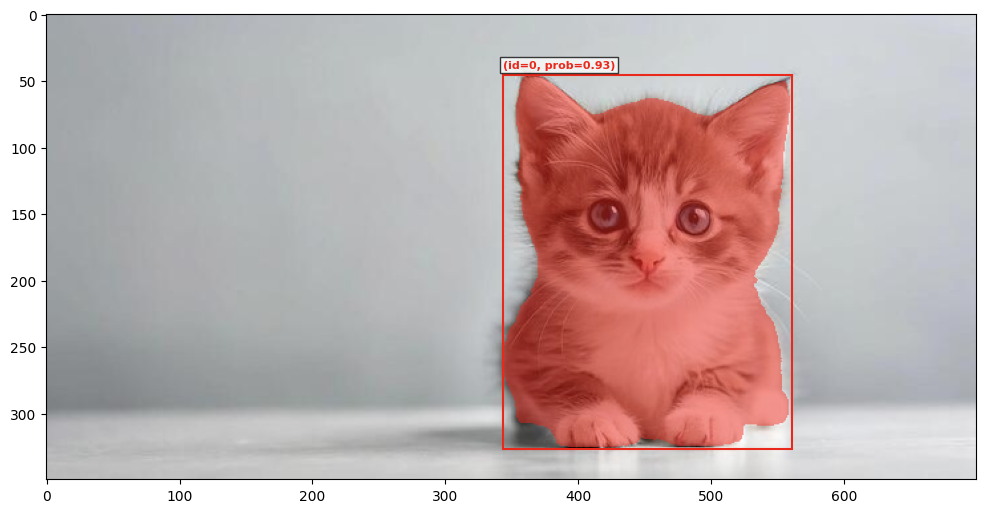

In [ ]:
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="cat")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

## Test model with example images from MRI/CT datasets

### Imports

In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import pandas as pd


In [ ]:
from sam3.model.sam3_image_processor import Sam3Processor

BASEDIR = "/content/drive/MyDrive/MSc_Thesis_Neuroimaging/"
model = build_sam3_image_model(bpe_path=bpe_path)
confidence_threshold = 0.25
processor = Sam3Processor(model, confidence_threshold=confidence_threshold)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

### Datasets

In [ ]:
datasets = {
    "MRI_tumor_binary": {
        "path": f"{BASE_DIR}/data/split/MRI_tumor_binary_norm/test",
        "modality": "MRI",
        "classes": ["normal", "tumor"]
    },
    "MRI_tumor_multiclass": {
        "path": f"{BASE_DIR}/data/split/MRI_tumor_multiclass_norm/test",
        "modality": "MRI",
        "classes": ["normal", "*oma", "*toma"]
    },
    "MRI_ms": {
        "path": f"{BASE_DIR}/data/split/MRI_ms_norm/test",
        "modality": "MRI",
        "classes": ["control", "MS"]
    },
    "CT_stroke": {
        "path": f"{BASE_DIR}/data/split/CT_stroke_binary_norm/test",
        "modality": "CT",
        "classes": ["normal", "stroke"]
    }
}

In [ ]:
def auto_detect_bbox(image_array, class_name):
    """Enhanced bbox detection per class"""

    if len(image_array.shape) == 3:
        gray = np.mean(image_array, axis=2)
    else:
        gray = image_array.copy()

    gray_norm = (gray - gray.min()) / (gray.max() - gray.min() + 1e-8)

    if "tumor" in class_name.lower():
        # Tumors: bright regions
        threshold = 0.35
        bright_pixels = gray_norm > threshold
    elif "ms" in class_name.lower():
        # MS lesions: small bright spots
        threshold = 0.4
        bright_pixels = gray_norm > threshold
    elif "stroke" in class_name.lower():
        # Stroke: dark regions
        threshold = 0.25
        bright_pixels = gray_norm < threshold
    elif "normal" in class_name.lower():
        # Normal: no segmentation expected
        h, w = gray.shape
        return [w//4, h//4, 3*w//4, 3*h//4]  # Center fallback
    else:
        # Default
        threshold = 0.3
        bright_pixels = gray_norm > threshold

    if bright_pixels.sum() < 50:  # Too few pixels
        h, w = gray.shape
        return [w//4, h//4, 3*w//4, 3*h//4]

    coords = np.where(bright_pixels)
    y_min, y_max = coords[0].min(), coords[0].max()
    x_min, x_max = coords[1].min(), coords[1].max()

    padding = 25
    h, w = gray.shape

    bbox = [
        max(0, x_min - padding),
        max(0, y_min - padding),
        min(w, x_max + padding),
        min(h, y_max + padding)
    ]

    return bbox

In [ ]:
import torch
import gc

torch.cuda.empty_cache()
gc.collect()

print("GPU memory cleared!")
print(f"Free GPU memory: {torch.cuda.memory_reserved()/1e9:.1f}GB")

In [ ]:
from sam3.visualization_utils import plot_bbox, plot_mask, COLORS

def save_plot_results(img, results, save_path):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)
    ax.axis("off")

    nb_objects = len(results["scores"])

    for i in range(nb_objects):
        color = COLORS[i % len(COLORS)]

        plot_mask(
            results["masks"][i].squeeze(0).cpu(),
            color=color,
            ax=ax,
        )

        w, h = img.size
        prob = results["scores"][i].item()

        plot_bbox(
            img_height=h,
            img_width=w,
            box=results["boxes"][i].cpu(),
            text=f"{prob:.2f}",
            box_format="XYXY",
            relative_coords=False,
            color=color,
            ax=ax,
        )

    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.close(fig)


In [ ]:
from pathlib import Path
SAVE_DIR = Path(f"{BASE_DIR}/sam3_plots")

In [ ]:
def evaluate_sam3(dataset_name, dataset_info, max_images_per_class=100):
    test_path = Path(dataset_info["path"])
    class_folders = []
    for pattern in dataset_info.get("classes", ["*"]):
        found = test_path.glob(pattern)
        class_folders.extend([f for f in found if f.is_dir()])

    print(f"\nFound {len(class_folders)} class folders: {[f.name for f in class_folders]}")

    results = []
    plot_info = []

    dataset_plots_dir = SAVE_DIR / dataset_name
    dataset_plots_dir.mkdir(parents=True, exist_ok=True)

    for class_folder in class_folders:
        class_name = class_folder.name

        if "normal" in class_name.lower() or "control" in class_name.lower():
            print(f"  ⏭️  Skipping: {class_name}")
            continue

        image_files = list(class_folder.glob("*.png")) + list(class_folder.glob("*.jpg"))

        if len(image_files) == 0:
            print(f"  ⚠️  No images in {class_name}")
            continue

        print(f"  🖼️  Processing {class_name}: {len(image_files)} images")

        for img_path in tqdm(image_files[:max_images_per_class], desc=f"  {class_name}"):
            try:
                image = Image.open(img_path)
                if image.mode != 'RGB':
                    image = image.convert('RGB')

                image_array = np.array(image)
                bbox = auto_detect_bbox(image_array, class_name)

                inference_state = processor.set_image(image)
                processor.reset_all_prompts(inference_state)
                prompt = "tumor" if "tumor" in class_name.lower() else "lesion"
                output = processor.set_text_prompt(state=inference_state, prompt=prompt)
                masks, boxes, scores = output["masks"], output["boxes"], output["scores"]
                best_score = scores.max().item() if len(scores) > 0 else 0.0
                n_objects = len(scores)
                success = 1 if (n_objects > 0 and best_score > 0.2) else 0

                results.append({
                    'dataset': dataset_name,
                    'class': class_name,
                    'image': img_path.name,
                    'n_objects': n_objects,
                    'best_score': best_score,
                    'success': success
                })

                # SAVE ALL SUCCESSFUL PLOTS
                if success:
                    img_test = Image.open(img_path)
                    plot_filename = f"{class_name}_{img_path.stem}_sam3.png"
                    save_path = dataset_plots_dir / plot_filename

                    save_plot_results(img_test, output, save_path)
                    plot_info.append({
                        'class': class_name,
                        'image': img_path.name,
                        'plot_path': str(save_path),
                        'n_objects': n_objects,
                        'best_score': best_score
                    })
                    print(f"  💾 Saved plot: {plot_filename}")

            except Exception as e:
                print(f"Error processing {img_path.name}: {e}")
                results.append({
                    'dataset': dataset_name,
                    'class': class_name,
                    'image': img_path.name,
                    'n_objects': 0,
                    'best_score': 0.0,
                    'success': 0
                })
    return pd.DataFrame(results), plot_info

In [ ]:
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results


In [ ]:
all_results = {}
all_plot_info = []

for dataset_name, info in datasets.items():
    try:
        results_df, plots_info = evaluate_sam3(dataset_name, info)
        all_results[dataset_name] = results_df
        all_plot_info.extend(plots_info)
    except Exception as e:
        print(f"Error in {dataset_name}: {e}")


Found 2 class folders: ['normal', 'tumor']
  ⏭️  Skipping: normal
  🖼️  Processing tumor: 225 images


  tumor:   3%|▎         | 3/100 [00:10<05:49,  3.60s/it]

  💾 Saved plot: tumor_y25_sam3.png


  tumor:   4%|▍         | 4/100 [00:13<05:18,  3.32s/it]

  💾 Saved plot: tumor_y1074_sam3.png


...

  💾 Saved plot: stroke_16044_sam3.png


  stroke:  99%|█████████▉| 99/100 [05:45<00:03,  3.24s/it]

  💾 Saved plot: stroke_12363_sam3.png


  stroke: 100%|██████████| 100/100 [05:49<00:00,  3.49s/it]

  💾 Saved plot: stroke_12102_sam3.png


In [ ]:
summary_data = []
total_images = 0
total_success = 0

for dataset_name, results_df in all_results.items():
    if len(results_df) > 0:
        n_images = len(results_df)
        n_success = results_df['success'].sum()
        success_rate = n_success / n_images
        avg_conf = results_df.loc[results_df['success'] == 1, 'best_score'].mean() if n_success > 0 else 0.0

        summary_data.append({
            'Dataset': dataset_name,
            'Images': n_images,
            'Success': f"{success_rate:.1%}",
            'Avg Conf': f"{avg_conf:.3f}"
        })

        total_images += n_images
        total_success += n_success


SAM3 RESULTS SUMMARY
             Dataset  Images Success Avg Conf
    MRI_tumor_binary     100   28.0%    0.588
MRI_tumor_multiclass     294   98.3%    0.458
              MRI_ms     100  100.0%    0.461
           CT_stroke     100  100.0%    0.432

Overall: 517/594 (87.0%)

CREATING CLASS REPRESENTATIVES GALLERY...


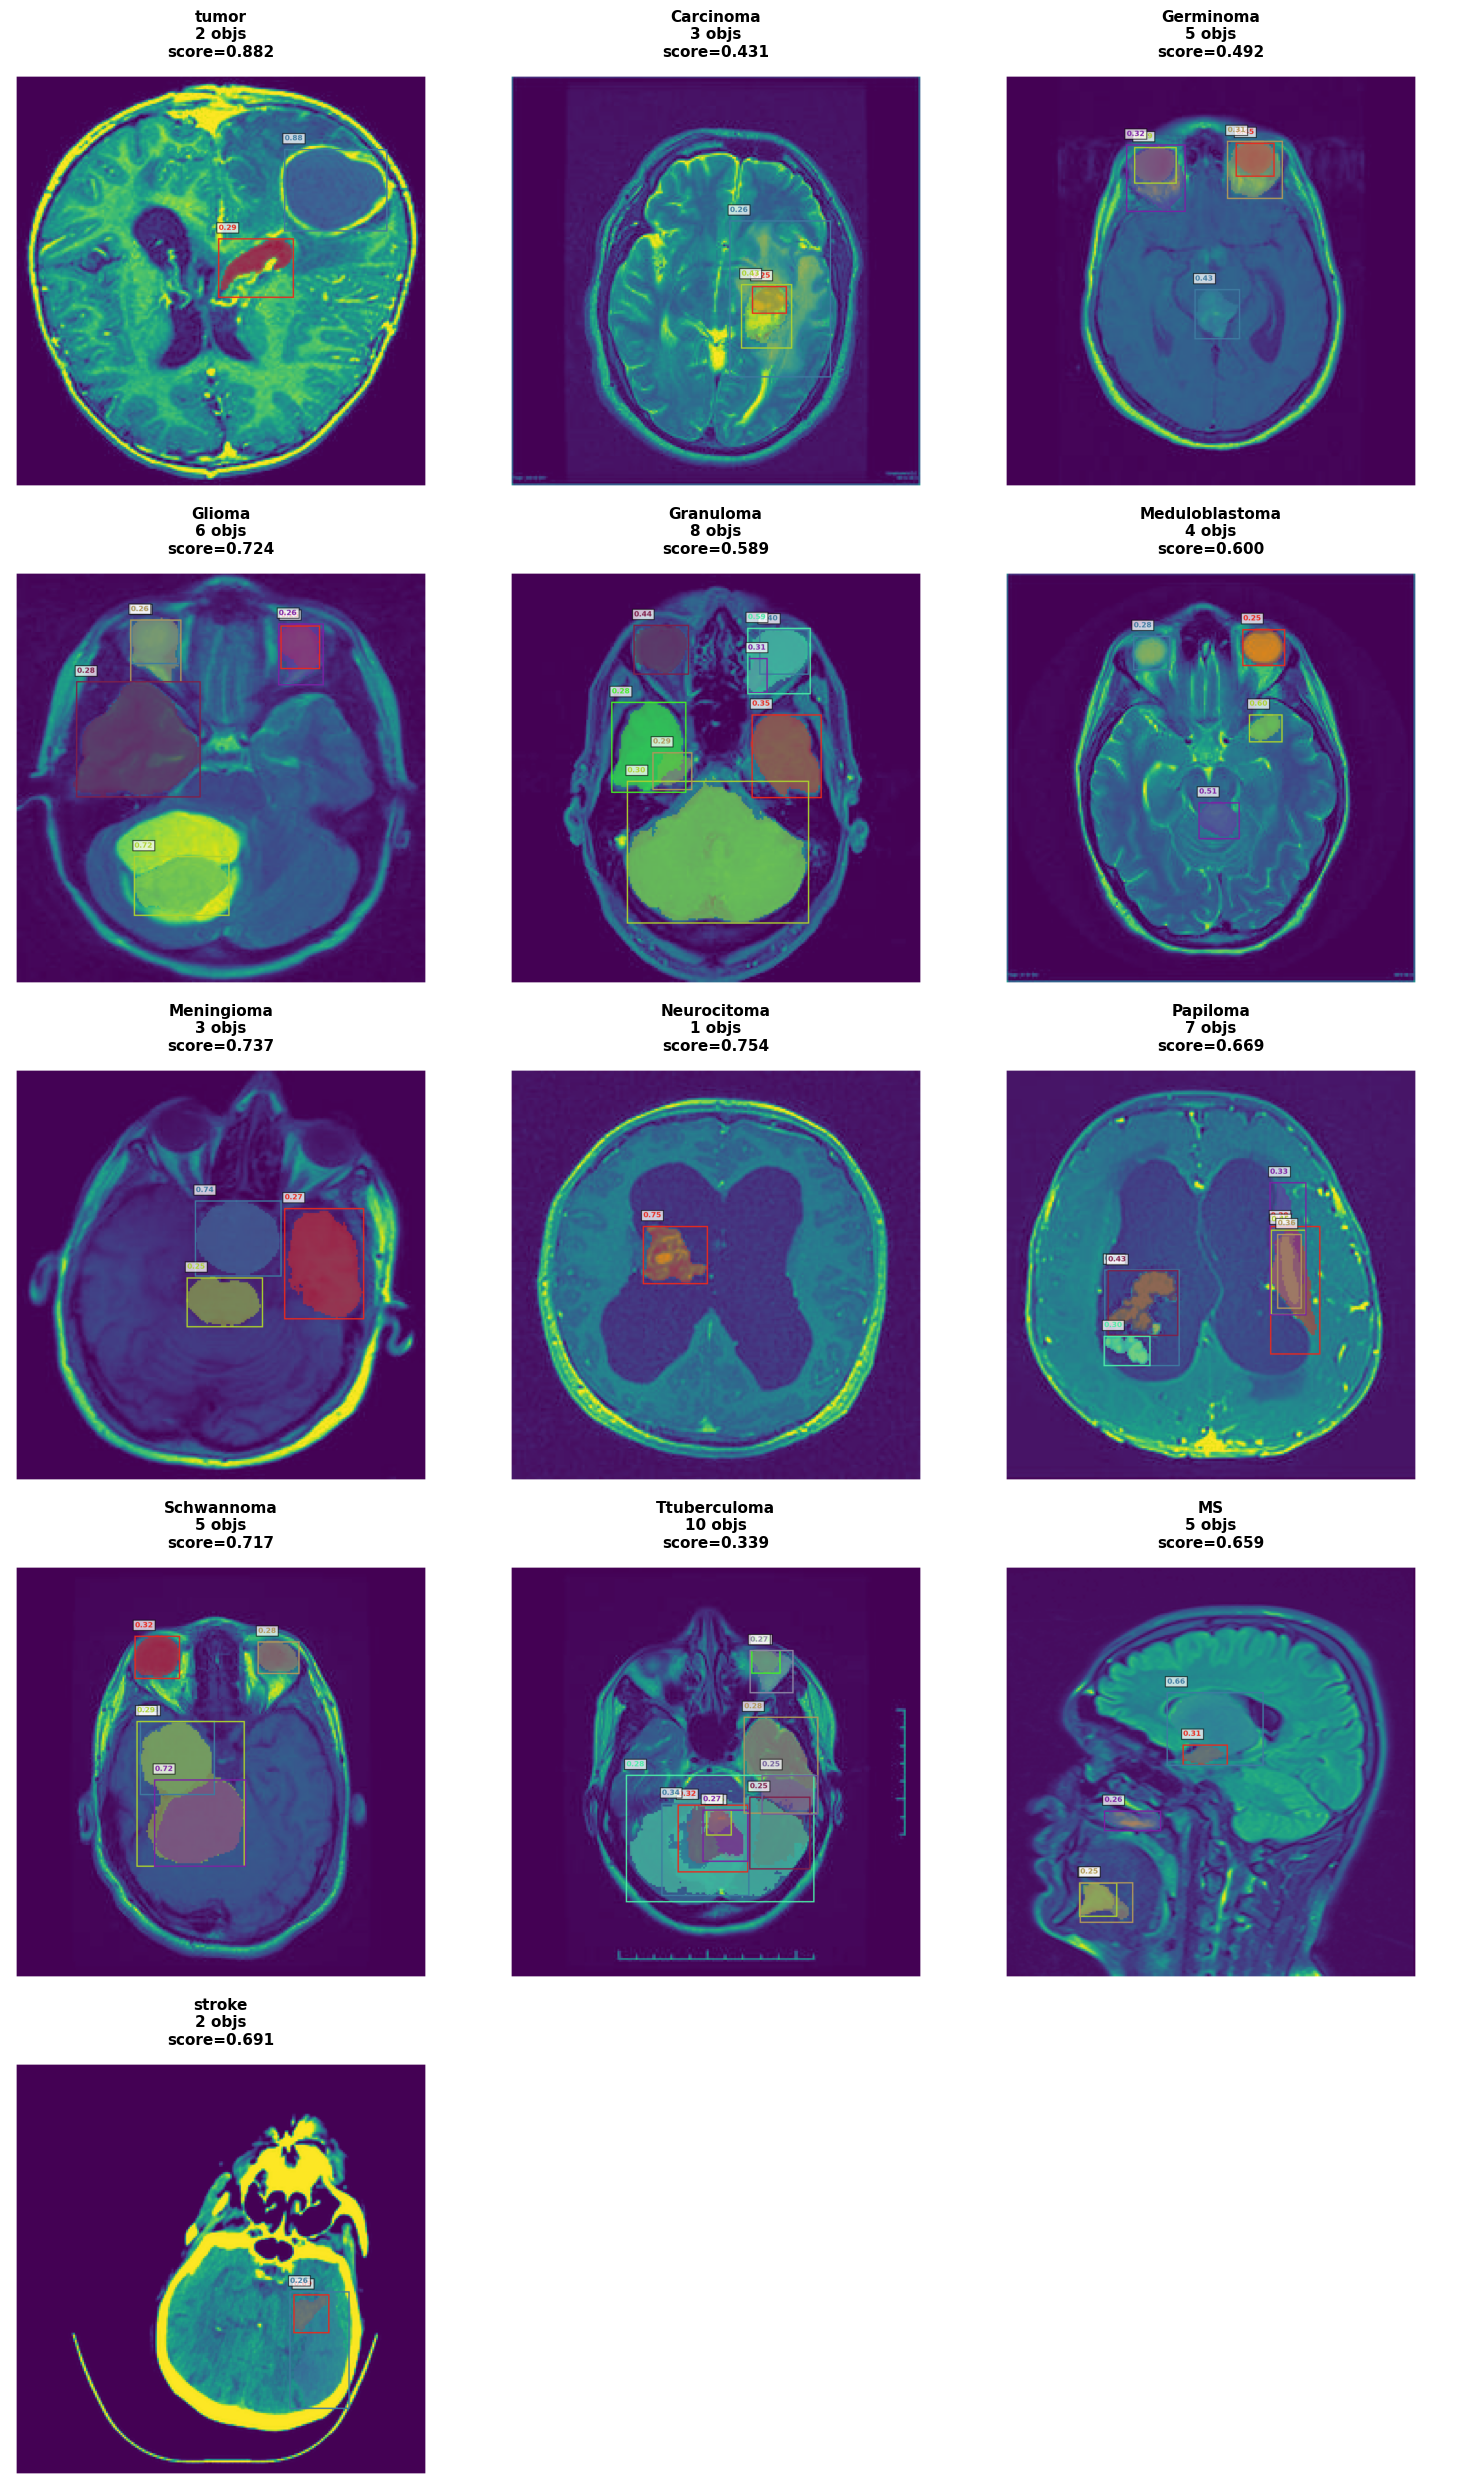

  🎨 Gallery saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/sam3_plots/class_representatives_gallery.png

📁 All plots: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/sam3_plots
   Total saved: 517


In [ ]:
if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print(f"\n{'='*80}")
    print("SAM3 RESULTS SUMMARY")
    print(f"{'='*80}")
    print(summary_df.to_string(index=False))
    print(f"\nOverall: {total_success}/{total_images} ({total_success/total_images:.1%})")

    print(f"\nCREATING CLASS REPRESENTATIVES GALLERY...")

    class_best_plots = {}
    for plot in all_plot_info:
        cls = plot['class']
        if cls not in class_best_plots or plot['best_score'] > class_best_plots[cls]['best_score']:
            class_best_plots[cls] = plot

    n_classes = len(class_best_plots)
    cols = min(3, n_classes)
    rows = (n_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    axes = np.array(axes).flatten() if n_classes > 1 else [axes]

    for idx, (class_name, plot_info) in enumerate(class_best_plots.items()):
        img = plt.imread(plot_info['plot_path'])
        axes[idx].imshow(img)
        axes[idx].set_title(f"{class_name}\n{plot_info['n_objects']} objs\nscore={plot_info['best_score']:.3f}",
                           fontsize=11, fontweight='bold', pad=10)
        axes[idx].axis('off')

    for i in range(n_classes, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    gallery_path = SAVE_DIR / "class_representatives_gallery.png"
    plt.savefig(gallery_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"  🎨 Gallery saved: {gallery_path}")

    print(f"\n📁 All plots: {SAVE_DIR}")
    print(f"   Total saved: {len(all_plot_info)}")

else:
    print("\n❌ No results!")